# Avance 4 — Modelos alternativos (Equipo 17, AgroSatCopilot)

## Proyecto Integrador MNA · Tec de Monterrey

**Equipo 17**

- Carlos Isaac Ávila Gutiérrez — A01796035
- Carlos Aaron Bocanegra Buitrón — A01796345
- Arthur Jafed Zizumbo Velasco — A01796363

**Curso**: Proyecto Integrador

**Sponsor académico**: Dr. Gerardo José Camacho — gjcamacho@tec.mx

**Fecha de entrega**: 2026-05-31.

---

## Resumen ejecutivo

Este cuaderno **consolida** las **6 arquitecturas individuales** (no ensambles) de segmentación semántica densa de cultivos sobre PASTIS-R, repartidas entre el equipo. Consume los parquets comparativos que cada integrante exporta, construye la tabla de los 6 modelos ordenada por la métrica principal (mIoU), selecciona el top-2, documenta el ajuste fino (Optuna) y la elección del modelo individual final.

| # | Modelo | Tipo |
|---|--------|------|
| 1 | U-Net ResNet-50 | CNN clásica 2D |
| 2 | DeepLabv3+ MobileNet | CNN eficiente ASPP |
| 3 | SegFormer-B0 | Transformer spatial |
| 4 | U-TAE | Temporal Attention |
| 5 | TSViT | Transformer temporal (Paper 1) |
| 6 | AnySat frozen + linear head | Foundation model congelado |


## Objetivos y rubrica

- **3.3** Explorar una gama diversa de tecnicas (6 arquitecturas).
- **3.4** Encontrar la configuracion optima (ajuste fino del top-2).

**Distribucion de puntos**:

- **Comparativa (60 pts)**: >=6 modelos, tabla ordenada por mIoU + F1-macro + pixel-accuracy + tiempos de entrenamiento.
- **Ajuste fino (30 pts)**: Optuna (>=30 trials) sobre los 2 mejores.
- **Modelo individual (10 pts)**: justificacion del final (trade-offs, no solo metrica).

In [20]:
# --- Setup Colab + Drive compartido del equipo ---
import os, sys
from pathlib import Path

# Mismo patron que 04_baseline: monta Drive y prefija las rutas con
# shared_folder_path (vacio en local).
_IN_COLAB = False
shared_folder_path = ''
try:
    from google.colab import drive
    drive.mount('/content/drive')
    shared_folder_path = '/content/drive/MyDrive/Integrador/'
    _IN_COLAB = True
except ImportError:
    pass

_search = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
if _IN_COLAB:
    _search = [Path('/content/agrosat-copilot'), *_search]
for _cand in _search:
    if (_cand / 'pyproject.toml').is_file():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        os.chdir(_cand)
        break
else:
    raise RuntimeError('No se encontro el repo agrosat-copilot (pyproject.toml).')

import matplotlib.pyplot as plt
import polars as pl
print('repo:', Path.cwd(), '| colab:', _IN_COLAB, '| drive:', shared_folder_path or '(local)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
repo: /content/agrosat-copilot | colab: True | drive: /content/drive/MyDrive/Integrador/


## Metodologia

- **Dataset**: PASTIS-R (2433 patches Sentinel-2 multitemporales, 20 clases, folds oficiales espacialmente disjuntos -> sin leakage).
- **Convencion compartida**: `num_classes=20`, `ignore_index=19` (void), resolucion **256px**, split train=folds[1,2,3] / val=fold[4] / test=fold[5].
- **Metricas**: mIoU (principal) + F1-macro + pixel-accuracy, todas pixel-level (`ml/eval/dense_metrics.py`).
- **Tracking**: 1 run MLflow por modelo con tag `architecture`.

## Comparativa de los 6 modelos (60 pts)

In [21]:
# --- Consolidar los parquets de los integrantes (desde el Drive compartido) ---
REPORTS = Path((shared_folder_path if shared_folder_path else '')
               + 'reports/segmentation/metrics')
FIGURES = Path((shared_folder_path if shared_folder_path else '')
               + 'reports/segmentation/figures')
# Los 6 modelos del Avance 4. El integrador muestra los que ya exportaron su
# parquet y deja placeholder para los pendientes (no hay que tocar el notebook).
EXPECTED = ['unet', 'anysat', 'deeplabv3plus', 'segformer', 'utae', 'tsvit']
parts = sorted(REPORTS.glob('model_comparison_avance4_*.parquet'))
_avail = {p.stem.replace('model_comparison_avance4_', '').replace('_fast', '')
          for p in parts}
print('disponibles:', sorted(_avail))
print('pendientes :', [m for m in EXPECTED if m not in _avail])

if parts:
    table = pl.concat([pl.read_parquet(p) for p in parts], how='vertical_relaxed')
    table = table.unique(subset=['model'], keep='last').sort('miou', descending=True)
else:
    print('Aun no hay parquets en', REPORTS)
    table = pl.DataFrame()

_cols = ['model', 'miou_grouped', 'f1_macro_grouped', 'pixel_accuracy_grouped',
         'miou', 'f1_macro', 'pixel_accuracy', 'train_time_s', 'epochs']
table.select([c for c in _cols if c in table.columns]) if table.height else table

disponibles: ['anysat', 'unet']
pendientes : ['deeplabv3plus', 'segformer', 'utae', 'tsvit']


model,miou_grouped,f1_macro_grouped,pixel_accuracy_grouped,miou,f1_macro,pixel_accuracy,train_time_s,epochs
str,f64,f64,f64,f64,f64,f64,f64,i64
"""anysat""",0.591262,0.720331,0.717393,0.445935,0.571575,0.750092,2.040434,30
"""unet""",0.452094,0.590586,0.723277,0.242317,0.346336,0.691786,1.2243,30


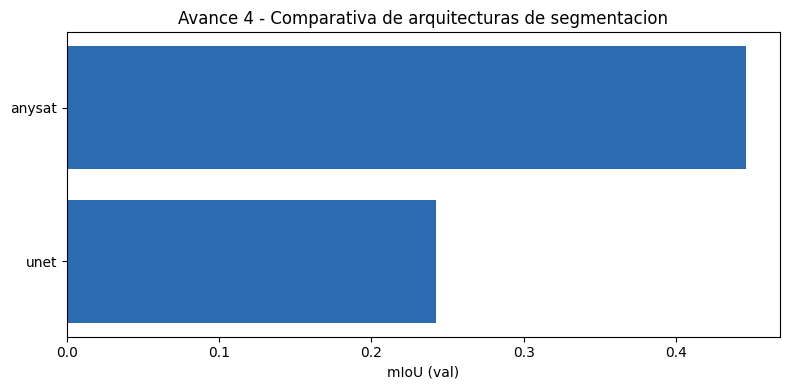

In [22]:
# --- Barplot comparativo (mIoU por modelo) ---
if table.height:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(table['model'].to_list()[::-1], table['miou'].to_list()[::-1], color='#2b6cb0')
    ax.set_xlabel('mIoU (val)')
    ax.set_title('Avance 4 - Comparativa de arquitecturas de segmentacion')
    fig.tight_layout()
    display(fig)
else:
    print('Tabla vacia: nada que graficar todavia.')

## Reportes visuales por modelo

Para cada modelo: curvas de entrenamiento, IoU por clase, matriz de confusión y la comparación RGB / verdad / predicción, tal como las dejó cada notebook en `reports/segmentation/figures/`. Los modelos que todavía no corrieron muestran un placeholder, así el cuaderno se completa solo a medida que cada uno entrena.

### unet

**Curvas de entrenamiento**

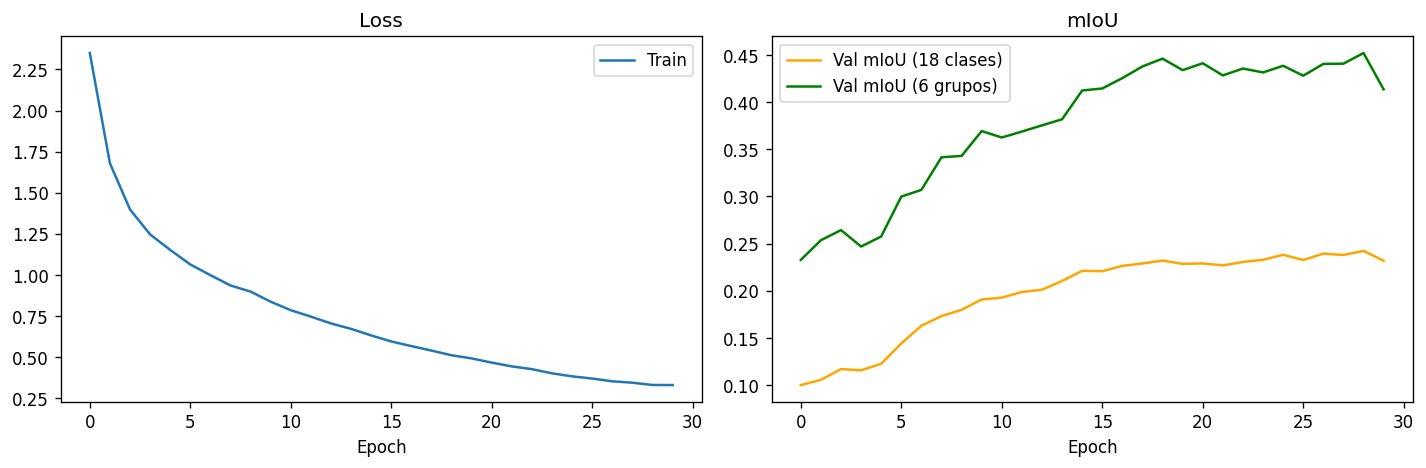

**IoU por clase**

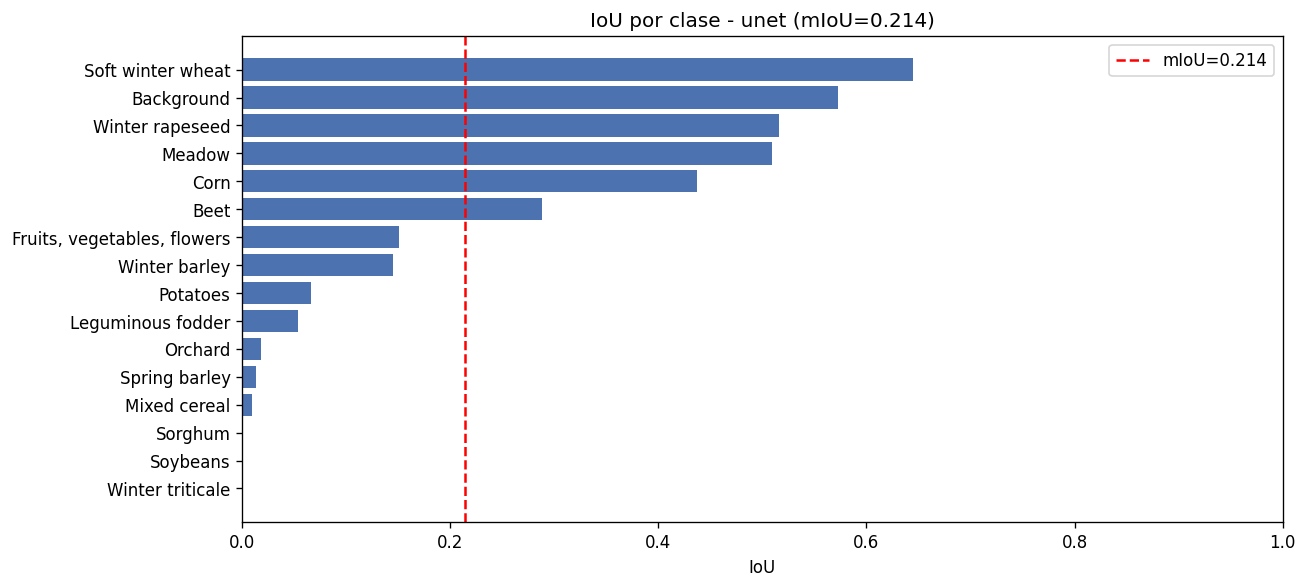

**Matriz de confusion**

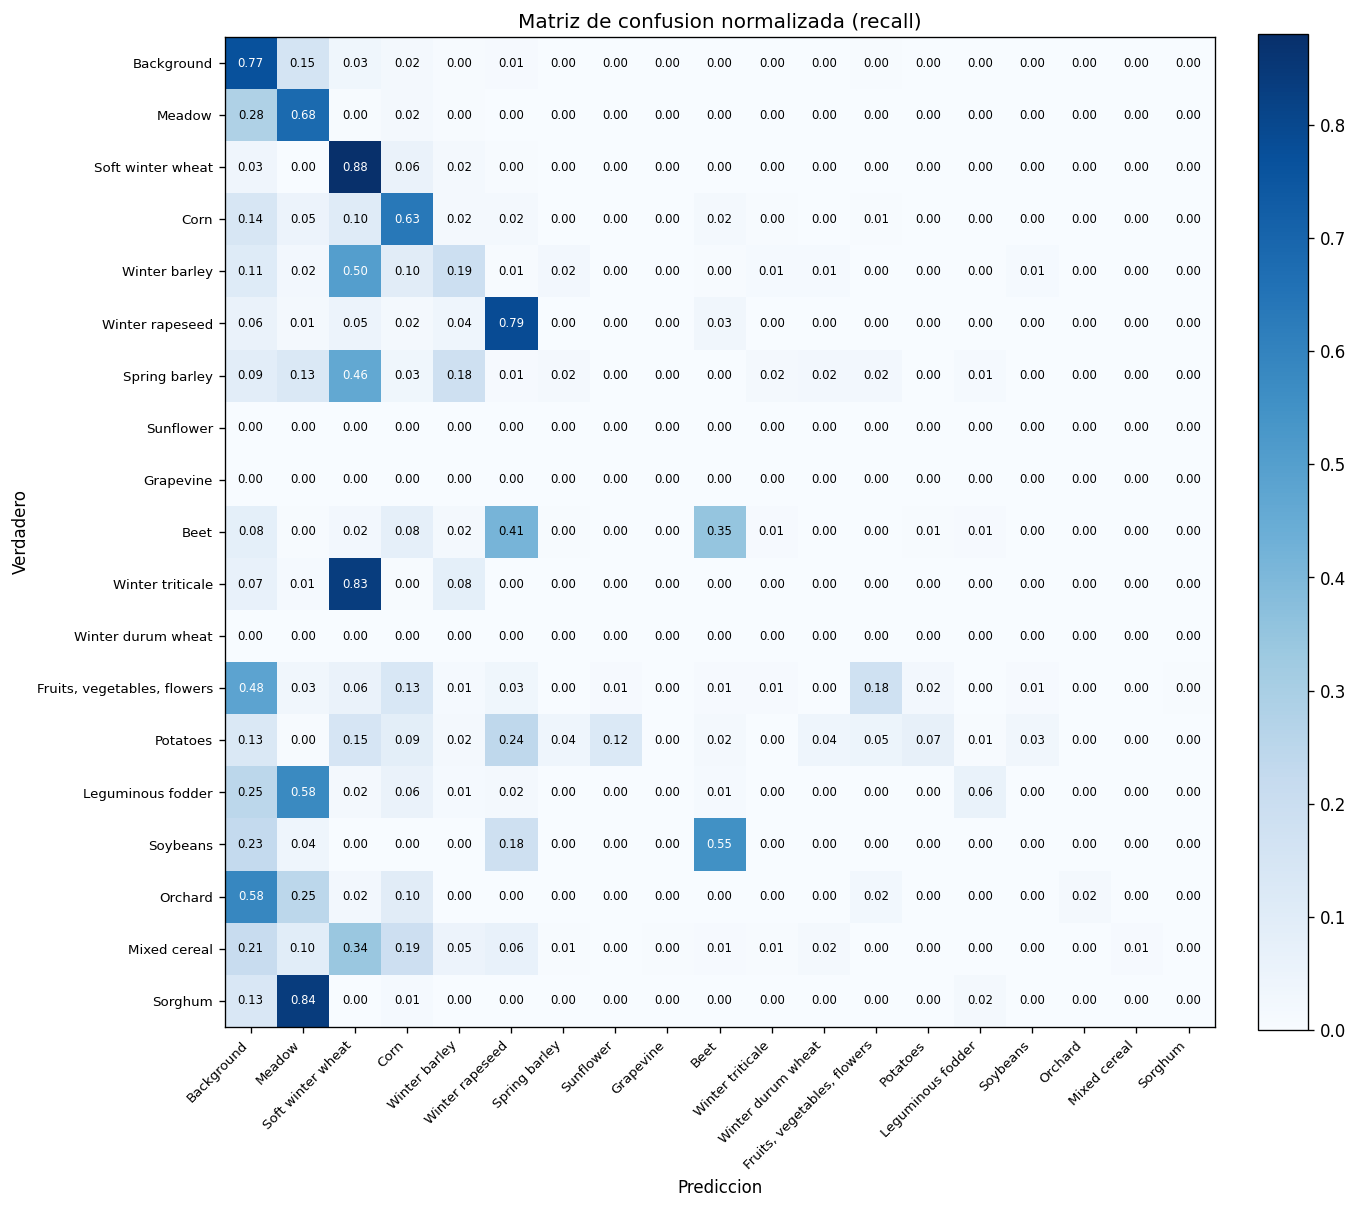

**RGB / verdad / prediccion**

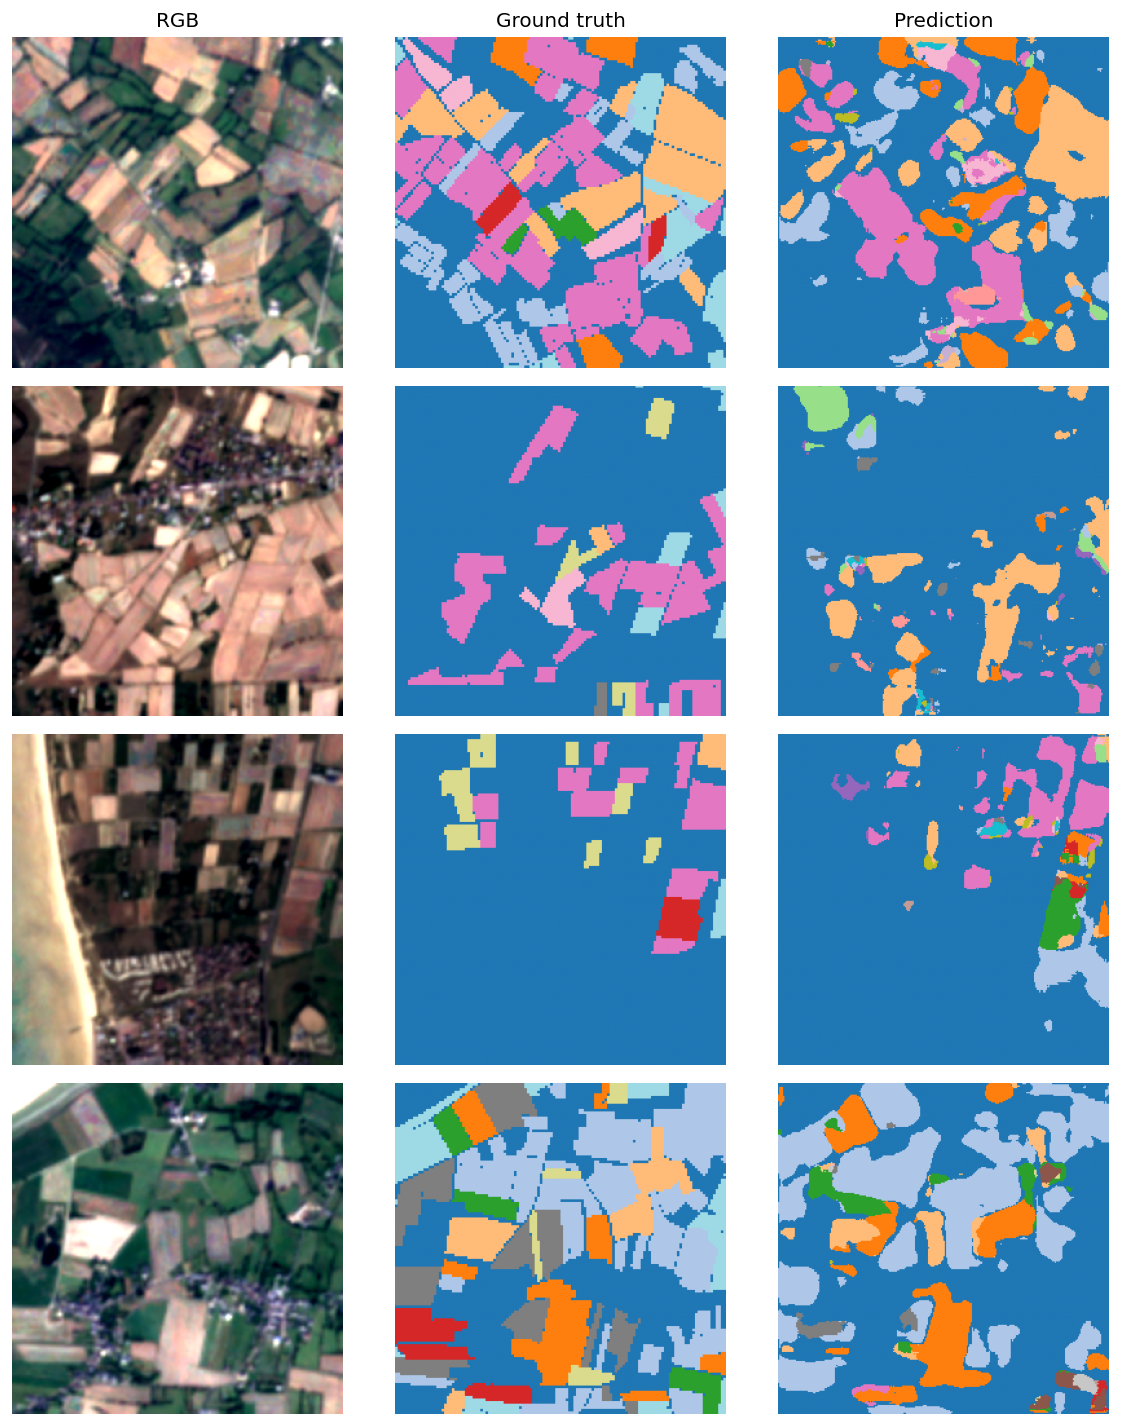

### anysat

**Curvas de entrenamiento**

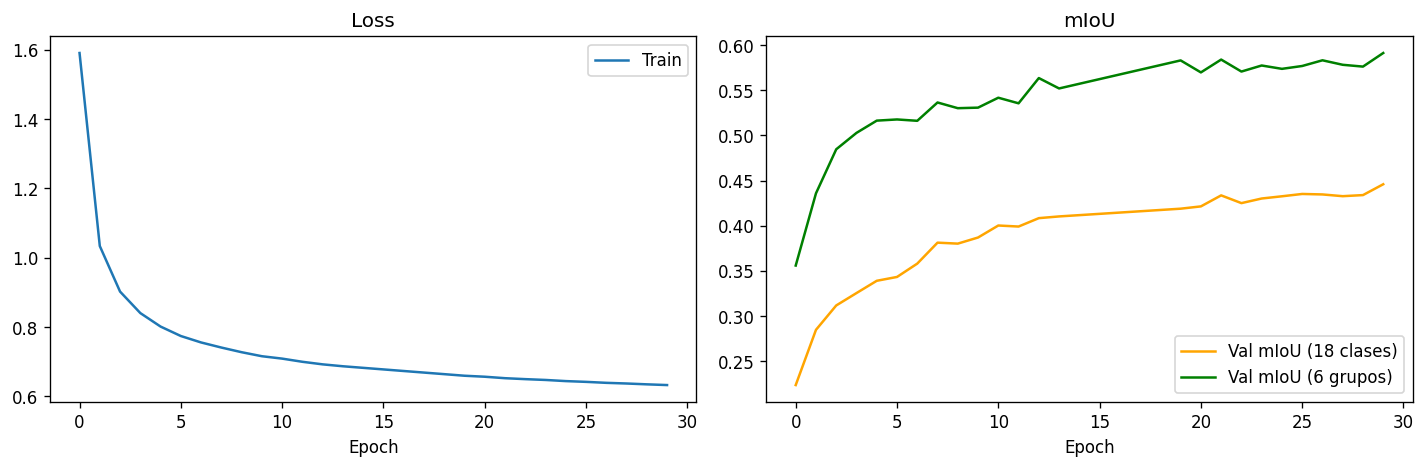

**IoU por clase**

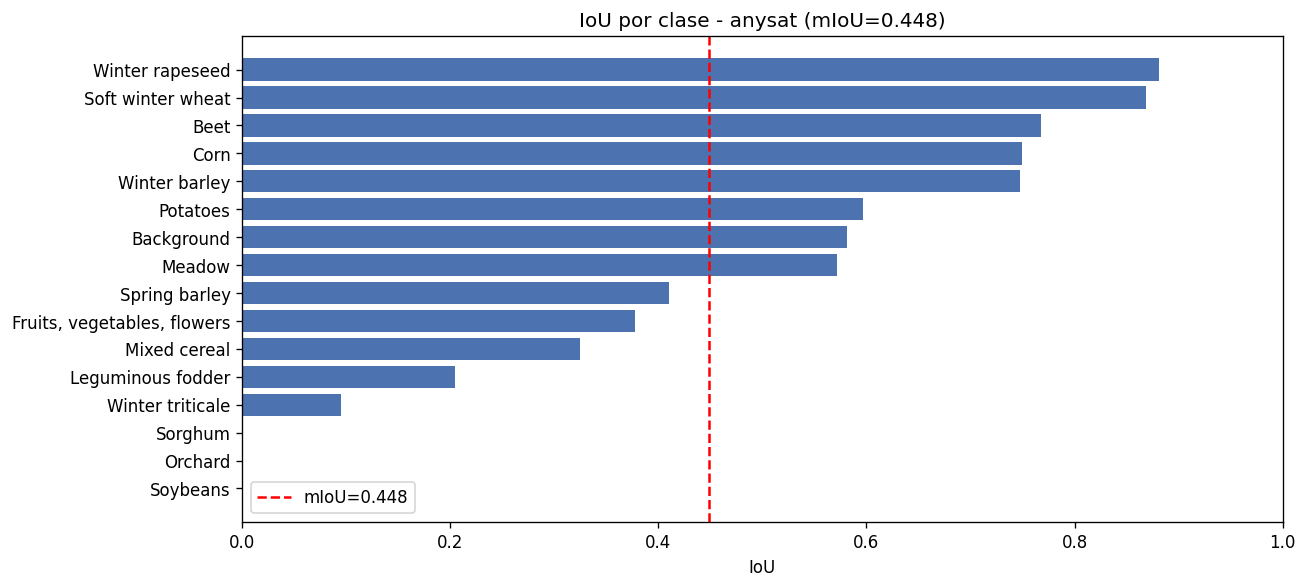

**Matriz de confusion**

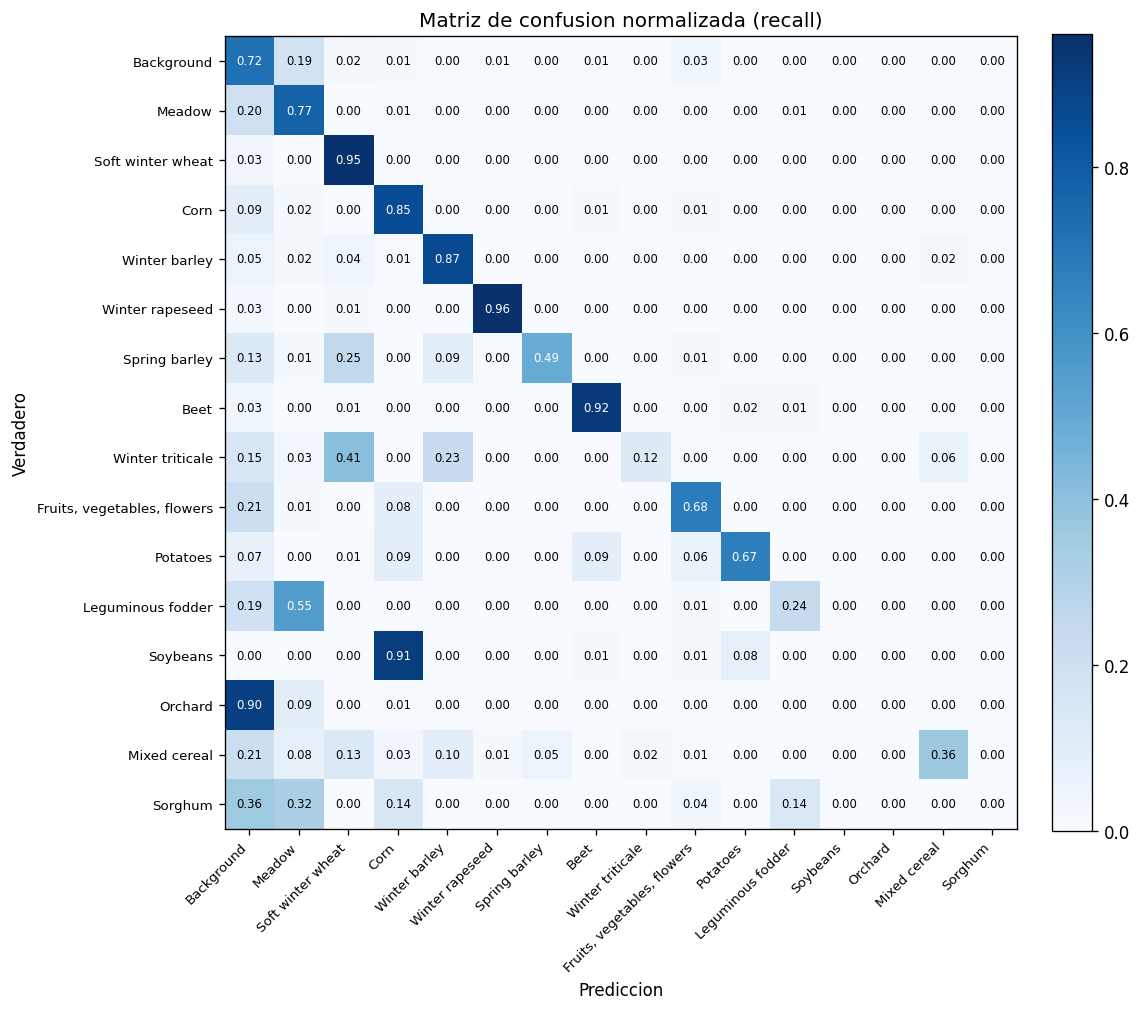

**RGB / verdad / prediccion**

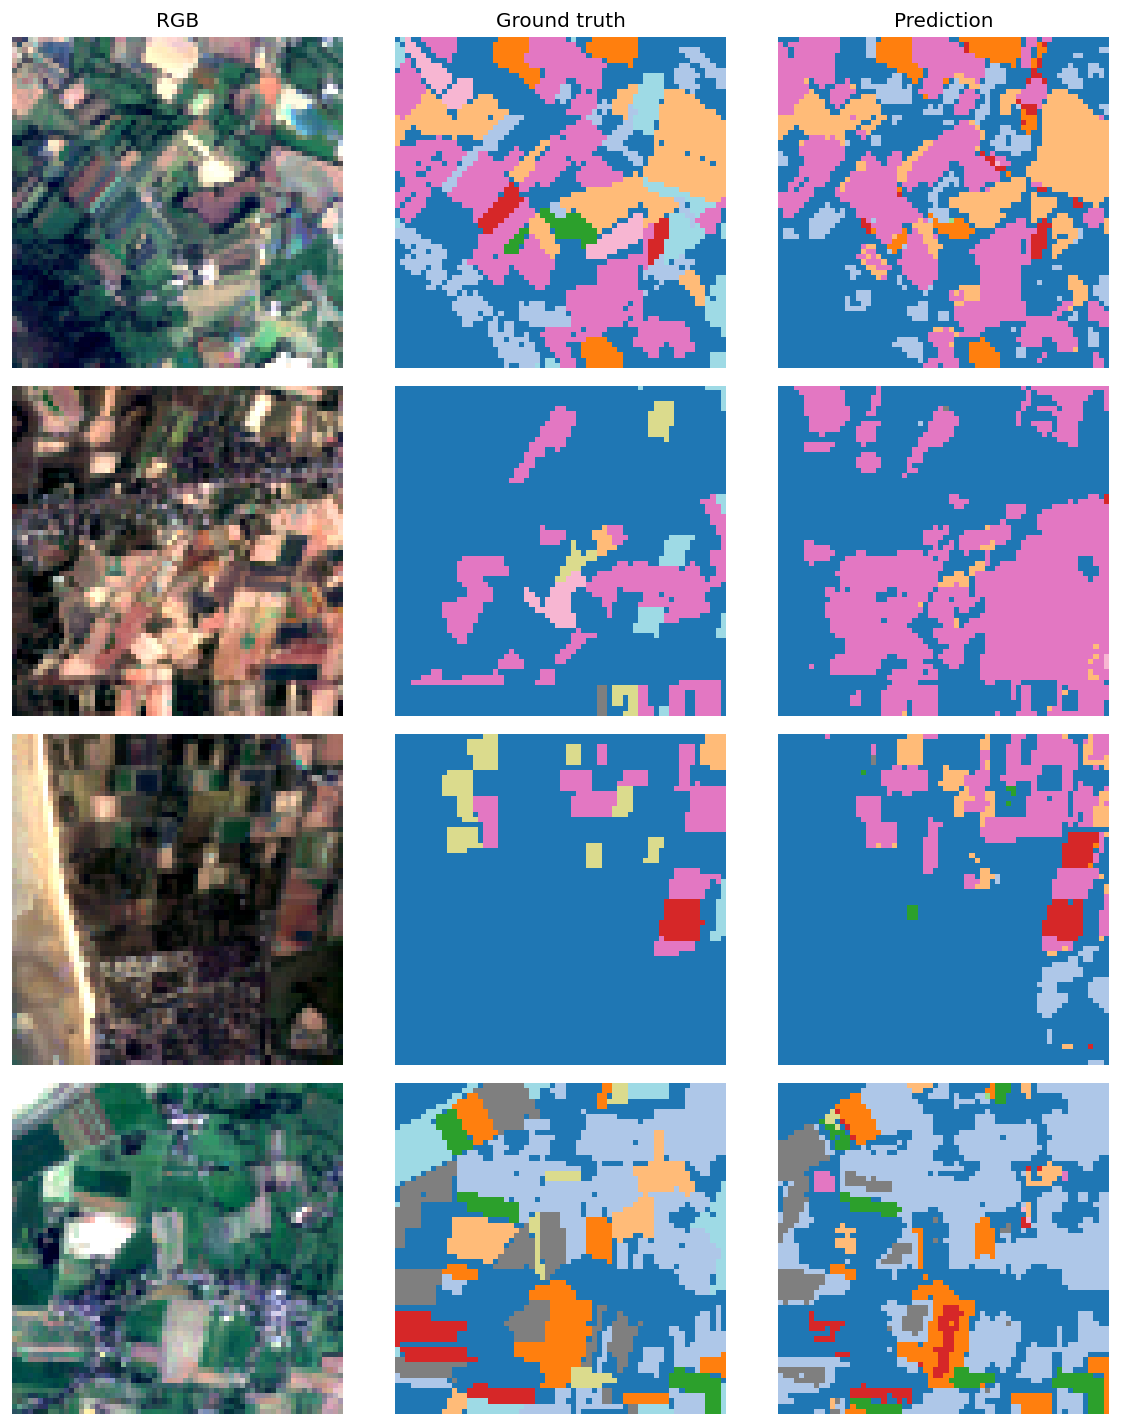

### deeplabv3plus

_Pendiente: aun no hay figuras para `deeplabv3plus` (correr su notebook de entrenamiento)._

### segformer

_Pendiente: aun no hay figuras para `segformer` (correr su notebook de entrenamiento)._

### utae

_Pendiente: aun no hay figuras para `utae` (correr su notebook de entrenamiento)._

### tsvit

_Pendiente: aun no hay figuras para `tsvit` (correr su notebook de entrenamiento)._

In [23]:
# --- Galeria de figuras por modelo (desde figures/ en Drive) ---
from IPython.display import Image, Markdown, display

def _find_fig(key, model):
    # Acepta el nombre exacto y variantes con sufijo (p.ej. anysat -> anysat_fast).
    _exact = FIGURES / f'{key}_{model}.png'
    if _exact.exists():
        return _exact
    _alt = sorted(FIGURES.glob(f'{key}_{model}_*.png'))
    return _alt[0] if _alt else None

_fig_types = [('curves', 'Curvas de entrenamiento'),
              ('per_class_iou', 'IoU por clase'),
              ('confusion', 'Matriz de confusion'),
              ('samples', 'RGB / verdad / prediccion')]
for _m in EXPECTED:
    display(Markdown(f'### {_m}'))
    _shown = False
    for _key, _label in _fig_types:
        _f = _find_fig(_key, _m)
        if _f is not None:
            display(Markdown(f'**{_label}**'))
            display(Image(filename=str(_f)))
            _shown = True
    if not _shown:
        display(Markdown(f'_Pendiente: aun no hay figuras para `{_m}` (correr su notebook de entrenamiento)._'))

## Seleccion de los 2 mejores modelos

Por la metrica principal (mIoU); empate se rompe por F1-macro -> pixel-accuracy.

In [24]:
# --- Top-2 ---
if table.height >= 2:
    top2 = table.head(2)
    print('Top-2 por mIoU:', top2['model'].to_list())
    top2.select([c for c in _cols if c in top2.columns])
else:
    print('Se requieren >=2 modelos para seleccionar el top-2.')
    top2 = table

Top-2 por mIoU: ['anysat', 'unet']


## Ajuste fino del top-2 (30 pts)

Cada modelo del top-2 se afina con **Optuna (>=30 trials)** sobre `lr`, `weight_decay` y `batch_size`, reusando `ml.train.train_segmentation.run_training` (ver el hook al final de cada notebook de modelo, p. ej. `04d_segmentation_unet`). Los resultados afinados se exportan a `reports/segmentation/metrics/tuning_<modelo>.parquet` y se cargan aqui.

In [25]:
# --- Resultados del ajuste fino (si existen) ---
# Cada notebook de modelo del top-2 corre Optuna y exporta tuning_<modelo>.parquet a metrics/.
tuning_parts = sorted(REPORTS.glob('tuning_*.parquet'))
if tuning_parts:
    tuning = pl.concat([pl.read_parquet(p) for p in tuning_parts], how='vertical_relaxed')
    display(tuning)
else:
    print('Pendiente: ejecutar la celda de Optuna en los notebooks del top-2 '
          f'({top2["model"].to_list() if table.height else "unet, anysat"}) '
          'para generar tuning_<modelo>.parquet.')
    tuning = pl.DataFrame()

Pendiente: ejecutar Optuna sobre el top-2 una vez confirmados los 6 modelos.


## Modelo individual final (10 pts)

Eleccion argumentada con trade-offs (no solo la metrica):

- **Rendimiento**: mIoU / F1-macro tras el ajuste fino.
- **Costo de computo**: tiempo de entrenamiento e inferencia (relevante para el presupuesto L4/H100 del proyecto).
- **Interpretabilidad y robustez**: las CNN (U-Net/DeepLabv3+) son mas simples de diagnosticar; los modelos temporales (U-TAE/TSViT) capturan fenologia; AnySat ofrece un FM congelado con minima capacidad entrenable.

> Completar tras la corrida real con el modelo ganador y su justificacion.

In [ ]:
# --- Modelo final + sus reportes visuales ---
from IPython.display import Image, Markdown, display
if table.height:
    final_model = table.row(0, named=True)['model']
    _r = table.row(0, named=True)
    display(Markdown(
        f'**Modelo individual final (por mIoU): `{final_model}`** - '
        f'mIoU 6 grupos = {_r.get("miou_grouped")}, '
        f'F1-macro 6 grupos = {_r.get("f1_macro_grouped")}'
    ))
    for _key in ('confusion', 'per_class_iou', 'samples'):
        _f = _find_fig(_key, final_model)
        if _f is not None:
            display(Image(filename=str(_f)))
else:
    print('Definir el modelo final tras consolidar los modelos.')

## Conclusiones y checklist de la rubrica

- [ ] **Comparativa (60)**: >=6 modelos en la tabla, ordenados por mIoU + F1-macro + pixel-accuracy + tiempos.
- [ ] **Ajuste fino (30)**: Optuna >=30 trials sobre el top-2, mejora documentada.
- [ ] **Modelo individual (10)**: final elegido con argumentos de trade-offs.

**Entrega**: liga de GitHub, ejecucion secuencial, nombre `Avance4.Equipo17`.